# **Trader Performance vs Market Sentiment**
## Primetrade.ai — Round 0 Assignment

**Objective:** Analyze how Bitcoin market sentiment (Fear/Greed) relates to trader behavior and performance on Hyperliquid.

**Datasets used:**
- Bitcoin Fear/Greed Index (2018–2025)
- Hyperliquid Historical Trader Data (2024–2025)

By: ***Khushi***

# ***Part A — Data Preparation***

In this section, we load both datasets, explore their structure, check data quality,
convert timestamps to a common date format, merge the datasets, and create key metrics
for analysis.

Datasets:
- Bitcoin Fear/Greed Index: daily market sentiment labels from 2018 to 2025
- Hyperliquid Trader Data: individual trade records from 32 traders across 2023–2025


In [3]:
import pandas as pd                         #for data manipulation
import numpy as np                          #for numerical calculations
import matplotlib.pyplot as plt             #for charts
import seaborn as sns                       #for beautiful and informative charts

import warnings
warnings.filterwarnings('ignore')           #hide unneccesary warnings

In [4]:
# DATA LOADING
fear_greed = pd.read_csv('fear_greed_index.csv')
trades = pd.read_csv('historical_data.csv')

# CHECK DATA LOADED CORRECTLY
print(f"Fear_Greed: {fear_greed.shape[0]} rows , {fear_greed.shape[1]} columns")
print(f"Trades: {trades.shape[0]} rows , {trades.shape[1]} columns")

Fear_Greed: 2644 rows , 4 columns
Trades: 211224 rows , 16 columns


In [5]:
# KNOWING DATA
print('FEAR_GREED COLUMNS:', fear_greed.columns.tolist())        #types of variable in fear_greed
print('\nSAMPLE ROWS:')
print(fear_greed.head(3))                                        #three sample rows

print('\nSENTIMENT TYPES:')
print(fear_greed['classification'].value_counts())               #distribution of categories in fear_greed dataset



print('\n')                                                      #types of variable in TRADES
print('\nTRADES COLUMNS:', trades.columns.tolist())
print('\nSAMPLE ROWS:')
print(trades.head(3))                                            #three sample rows

print('\n UNIQUE TRADERS:',trades['Account'].nunique())          #no.of unique traders

print('\nBUY vs SELL')
print(trades['Side'].value_counts())                             #distribution of buying and selling


FEAR_GREED COLUMNS: ['timestamp', 'value', 'classification', 'date']

SAMPLE ROWS:
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03

SENTIMENT TYPES:
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64



TRADES COLUMNS: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

SAMPLE ROWS:
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   

   Size Tokens  Size USD Sid

In [6]:
# CHECK MISSING VALUES

print('MISSING VALUES - FEAR_GREED')
print(fear_greed.isnull().sum())


print('\nMISSING VALUES - TRADES')
print(trades.isnull().sum())


# CHECK DUPLICATE ROWS
print("Duplicate rows - Fear_Greed:", fear_greed.duplicated().sum())
print("Duplicate rows - Trades:", trades.duplicated().sum())

MISSING VALUES - FEAR_GREED
timestamp         0
value             0
classification    0
date              0
dtype: int64

MISSING VALUES - TRADES
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
Duplicate rows - Fear_Greed: 0
Duplicate rows - Trades: 0


### **Data Quality Check**
- Fear_Greed dataset: 2,644 rows, 0 missing values
- Trades dataset: 211,224 rows, 0 missing values
- No duplicate rows in any of the dataset
- 32 unique traders identified
- No cleaning required — data is complete

In [7]:
                                                  #### DATA PREPARATION  ####


# CONVERT TIMESTAMP TO DATE FORMAT
trades['date'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True).dt.date.astype(str)
fear_greed['date'] = pd.to_datetime(fear_greed['date']).dt.date.astype(str)


# SIMPLIFY SENTIMENT LABELS
def simplify_sentiment(c):
    if c in ['Fear', 'Extreme Fear']:
        return 'Fear'
    elif c in ['Greed', 'Extreme Greed']:
        return 'Greed'
    else:
        return 'Neutral'

# APPLY SENTIMENT FUNCTION TO EVERY ROW
fear_greed['sentiment'] = fear_greed['classification'].apply(simplify_sentiment)


In [8]:
# MERGE DATASETS
merged = trades.merge(fear_greed[['date','value','sentiment']],on='date',how='inner')
print(merged.head())


# TRADES DROPPED
print('\nTrades dropped:',len(trades)-len(merged))

# RANGE OF DATA AFTER MERGE
print(f"\nDate range: {merged['date'].min()} to {merged['date'].max()}")


# DISTRIBUTION OF SENTIMENTS
print(f"\nSentiment distribution:")
print(merged['sentiment'].value_counts())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

### **Data Preparation Complete**
- Converted timestamps to daily dates for alignment
- Simplified 5 sentiment categories into 3: Fear, Neutral, Greed
- Merged datasets on date — 211,218 trades retained (only 6 dropped)
- Date range: May 2023 to May 2025
- Greed days show higher trading activity (90,295) vs Fear days (83,237)
- This suggests traders are more active when market sentiment is positive



In [62]:
                                                      ###KEY METRICS###


# CALCULATE DAILY PNL

daily_pnl = merged.groupby(['Account','date'])['Closed PnL'].sum().reset_index(name='Daily PnL')
daily_pnl.head()

,Account,date,Daily PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


In [10]:
# CALCULATE WIN RATE

merged['is_win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby('Account')['is_win'].mean().mul(100).reset_index(name='Win_Rate%')
win_rate.head()

,Account,Win_Rate%
0,0x083384f897ee0f19899168e3b1bec365f52a9012,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,44.271978
2,0x271b280974205ca63b716753467d5a371de622ab,30.191651
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,43.858463
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,51.991355


In [1]:
# AVERAGE TRADE SIZE FOR EACH TRADER

avg_trade_size = merged.groupby('Account')['Size USD'].mean().reset_index(name='Avg_Trade_Size')
avg_trade_size.head()

NameError: name 'merged' is not defined

In [12]:
# LONG/SHORT RATIO

merged['long_ratio']= merged['Side']=='BUY'
merged['short_ratio']= merged['Side']=='SELL'

long_ratio = merged.groupby('Account')['long_ratio'].mean().mul(100).reset_index(name='Long_Ratio(%)')
long_ratio.head()

short_ratio = merged.groupby('Account')['short_ratio'].mean().mul(100).reset_index(name='Short_Ratio(%)')
short_ratio.head()

,Account,Short_Ratio(%)
0,0x083384f897ee0f19899168e3b1bec365f52a9012,55.185961
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,58.035714
2,0x271b280974205ca63b716753467d5a371de622ab,58.886847
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,49.673203
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,63.599877


In [13]:
# TRADE FREQUENCY OF EACH TRADER

trade_frequency = merged.groupby('Account').size().reset_index(name='Trade_Frequency')
trade_frequency.head()


,Account,Trade_Frequency
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280
2,0x271b280974205ca63b716753467d5a371de622ab,3809
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239


In [14]:
# PnL VOLATILITY OF EACH TRADER:

pnl_vol = merged.groupby('Account')['Closed PnL'].std().reset_index(name='PnL_Volatility')
pnl_vol.head()

,Account,PnL_Volatility
0,0x083384f897ee0f19899168e3b1bec365f52a9012,4692.452329
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,134.073473
2,0x271b280974205ca63b716753467d5a371de622ab,542.182659
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,113.269353
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,255.829091


In [15]:
# NUMBER OF TRADES PER DAY

trades_per_day = (merged.groupby('date').size().reset_index(name='Number_of_Trades'))
trades_per_day.head()

,date,Number_of_Trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


In [65]:
# OVERALL METRIC SUMMARY

print(f"Overall win rate: {merged['is_win'].mean()*100:.2f}%")
print(f"Overall long ratio: {merged['long_ratio'].mean()*100:.2f}%")
print(f"Avg trade size: ${merged['Size USD'].mean():.2f}")
print(f"Avg PnL per trade: ${merged['Closed PnL'].mean():.4f}")
print(f"PnL volatility (std): ${merged['Closed PnL'].std():.2f}")

Overall win rate: 41.12%
Overall long ratio: 48.62%
Avg trade size: $5639.19
Avg PnL per trade: $48.5493
PnL volatility (std): $917.99


## ***Part A — Summary***




### *Datasets Loaded*
- Bitcoin Fear/Greed Index: 2,644 rows | 4 columns | Date range: 2018 to 2025
- Hyperliquid Trader Data: 211,224 rows | 16 columns | 32 unique traders

### *Data Quality*
- Missing values: 0 in both datasets
- Duplicate rows: 0 in both datasets
- No cleaning required — data was complete

### *Data Preparation*
- Converted trader timestamps to daily date format (DD-MM-YYYY → YYYY-MM-DD)
- Simplified 5 sentiment labels into 3 groups:
  Fear + Extreme Fear → Fear
  Greed + Extreme Greed → Greed
  Neutral → Neutral
- Merged both datasets on date — 211,218 trades retained, only 6 dropped

### *Key Metrics Created (per trader)*
- Daily PnL — total profit/loss per trader per day
- Win Rate — percentage of profitable trades
- Average Trade Size — average capital deployed per trade
- Long/Short Ratio — directional bias of each trader
- Trade Frequency — total number of trades per trader
- Trades per Day — daily trading activity
- PnL Volatility — consistency of returns

### *Leverage Note*
Direct leverage data is not available in this dataset.
Leverage distribution analysis could not be performed.

### *Overall Baseline (before sentiment split)*
- Overall win rate: 41.12%
- Overall long ratio: 48.62%
- Average trade size: $5,639
               
- Average PnL per trade: $48.55

- PnL volatility: $917.99

### *Key Observation*
Greed days attract more trading activity (90,295 trades) compared to
Fear days (83,237 trades) — suggesting traders are more active when
market sentiment is positive. This is our first hint that sentiment
influences trader behaviour.

# ***Part B — Analysis***


## **Question 1:**
### ***Does trading performance differ across Fear, Greed and Neutral market sentiments?***

To answer this question, trading performance is evaluated using the following metrics:

- Average Profit and Loss (PnL)
- Win Rate
- Drawdown Proxy (largest realized loss)
- Average Trade Size
- Total Number of Trades


In [19]:
# QUESTION 1:


# GROUP BY SENTIMENTS
q1 = merged.groupby('sentiment').agg(
    Avg_PnL=('Closed PnL', 'mean'),
    Win_Rate=('is_win', 'mean'),
    Drawdown_Proxy=('Closed PnL', 'min'),
    Avg_Trade_Size=('Size USD', 'mean'),
    Total_Trades=('Trade ID', 'count')
).round(2).reset_index()

q1['Win_Rate'] = q1['Win_Rate'].mul(100).round(2)

print("Performance by Sentiment:")
print(q1)

Performance by Sentiment:
  sentiment  Avg_PnL  Win_Rate  Drawdown_Proxy  Avg_Trade_Size  Total_Trades
0      Fear    49.21      41.0       -35681.75         7182.01         83237
1     Greed    53.88      42.0      -117990.10         4574.42         90295
2   Neutral    34.31      40.0       -24500.00         4782.73         37686


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")

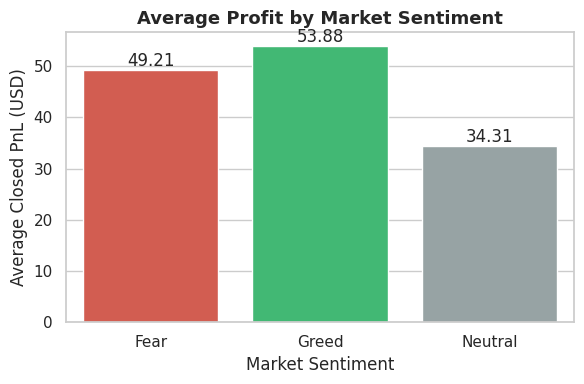

In [41]:
# MARKET SENTIMENT vs AVERAGE PNL

plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=q1,
    x='sentiment',
    y='Avg_PnL',
    hue='sentiment',
    palette=['#e74c3c','#2ecc71','#95a5a6'],
    legend=False
)

plt.title('Average Profit by Market Sentiment', fontsize=13, weight='bold')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Closed PnL (USD)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.savefig('chart1.png', dpi=150, bbox_inches='tight')
plt.show()


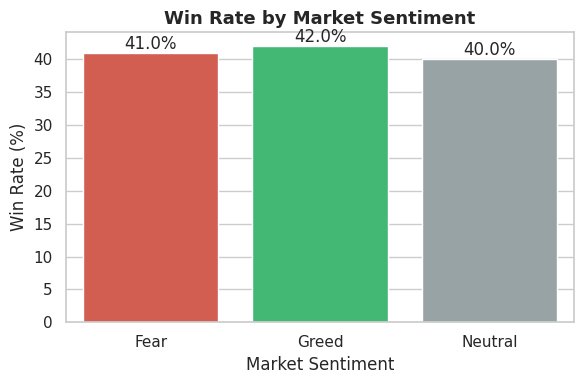

In [42]:
# MARKET SENTIMENT vs WIN RATE

plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=q1,
    x='sentiment',
    y='Win_Rate',
    hue='sentiment',
    palette=['#e74c3c','#2ecc71','#95a5a6'],
    legend=False
)

plt.title('Win Rate by Market Sentiment', fontsize=13, weight='bold')
plt.xlabel('Market Sentiment')
plt.ylabel('Win Rate (%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.savefig('chart2_performance.png', dpi=150, bbox_inches='tight')
plt.show()

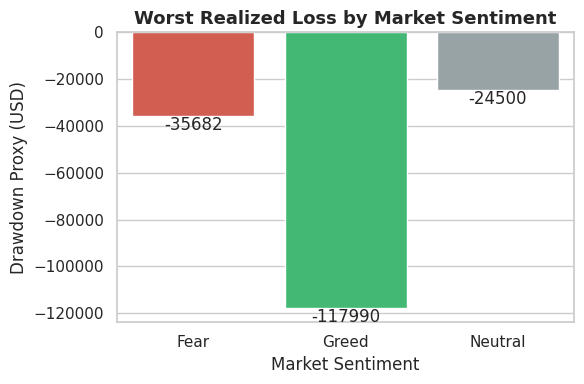

In [43]:
# MARKET SENTIMENT vs DRAWDOWN PROXY

plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=q1,
    x='sentiment',
    y='Drawdown_Proxy',
    hue='sentiment',
    palette=['#e74c3c','#2ecc71','#95a5a6'],
    legend=False
)

plt.title('Worst Realized Loss by Market Sentiment', fontsize=13, weight='bold')
plt.xlabel('Market Sentiment')
plt.ylabel('Drawdown Proxy (USD)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.tight_layout()
plt.savefig('chart3_performance.png', dpi=150, bbox_inches='tight')
plt.show()

#### ***Question 1 — SUMMARY***

- Average PnL is slightly higher on Greed days ($53.88) vs Fear days ($49.21)
- Win rates are nearly identical across sentiments (40-42%) —
  sentiment does not significantly affect whether a trade wins or loses
- Most surprising finding: the worst drawdown occurs on Greed days
  (-$117,990) vs Fear days (-$35,681) — suggesting traders take
  their biggest risks and losses during optimistic market conditions
- Neutral days show the lowest average PnL ($34.31) —
  indecisive markets lead to weaker performance

## **QUESTION 2:**
### ***Do traders change their trading behavior based on market sentiment?***

To answer this question, trader behavior is analyzed using the following metrics:

- Trade Frequency (Number of Trades)
- Average Position Size (Size USD)
- Long vs Short Bias

> **Note:** The dataset does not contain a leverage column. Therefore, leverage distribution cannot be analyzed directly. Instead, average trade size (Size USD) is used as an indicator of trading exposure.

In [39]:
# Question 2: BEHAVIOUR ANALYSIS BASED ON MAKE



q2 = (
    merged.groupby('sentiment')
    .agg(
        Trade_Frequency=('Trade ID', 'count'),
        Avg_Position_Size=('Size USD', 'mean'),
        Long_Ratio=('long_ratio', 'mean')
    )
    .round(2)
    .reset_index()
)


q2['Long_Ratio'] = (q2['Long_Ratio'] * 100).round(2)

q2['Short_Ratio'] = (100 - q2['Long_Ratio']).round(2)

print("Trading Behaviour by Sentiment:")
print(q2)

Trading Behaviour by Sentiment:
  sentiment  Trade_Frequency  Avg_Position_Size  Long_Ratio  Short_Ratio
0      Fear            83237            7182.01        50.0         50.0
1     Greed            90295            4574.42        47.0         53.0
2   Neutral            37686            4782.73        50.0         50.0


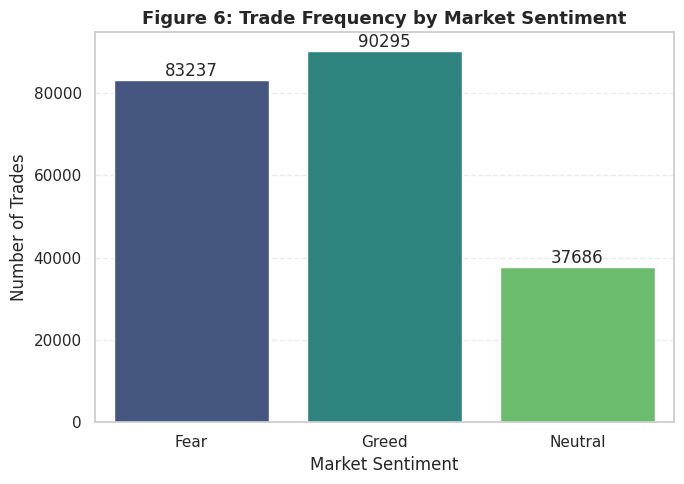

In [44]:
# SENTIMENT vs TRADE FREQUENCY

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=q2,
    x='sentiment',
    y='Trade_Frequency',
    hue='sentiment',
    palette='viridis',
    legend=False
)

plt.title('Figure 6: Trade Frequency by Market Sentiment',
          fontsize=13, weight='bold')

plt.xlabel('Market Sentiment')
plt.ylabel('Number of Trades')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('chart4_behaviour.png', dpi=150, bbox_inches='tight')
plt.show()

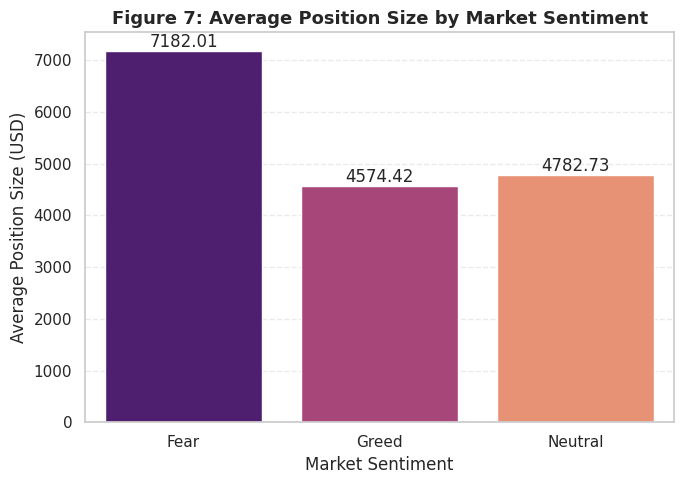

In [49]:
# SENTIMENT vs AVERAGE POSITION SIZE

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=q2,
    x='sentiment',
    y='Avg_Position_Size',
    hue='sentiment',
    palette='magma',
    legend=False
)

plt.title('Figure 7: Average Position Size by Market Sentiment',
          fontsize=13, weight='bold')

plt.xlabel('Market Sentiment')
plt.ylabel('Average Position Size (USD)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('chart5_behaviour.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 700x500 with 0 Axes>

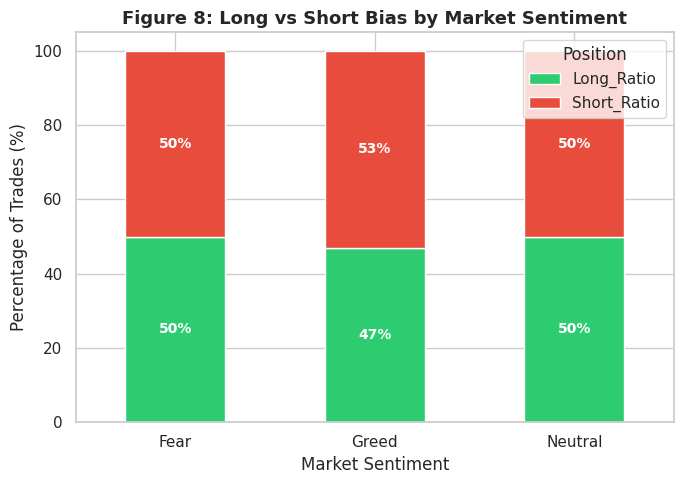

In [50]:
# LONG VS SHORT BIAS BY MARKET SENTIMENT

plot_data = q2.set_index('sentiment')[['Long_Ratio', 'Short_Ratio']]

plt.figure(figsize=(7,5))

plot_data.plot(
    kind='bar',
    stacked=True,
    figsize=(7,5),
    color=['#2ecc71', '#e74c3c']
)

plt.title('Figure 8: Long vs Short Bias by Market Sentiment',
          fontsize=13, weight='bold')

plt.xlabel('Market Sentiment')
plt.ylabel('Percentage of Trades (%)')

plt.xticks(rotation=0)
plt.yticks(range(0, 101, 20))
plt.legend(title='Position')

# Add percentage labels
for i in range(len(plot_data)):
    long = plot_data.iloc[i]['Long_Ratio']
    short = plot_data.iloc[i]['Short_Ratio']

    plt.text(i, long/2,
             f'{long:.0f}%',
             ha='center',
             va='center',
             color='white',
             fontsize=10,
             fontweight='bold')

    plt.text(i, long + short/2,
             f'{short:.0f}%',
             ha='center',
             va='center',
             color='white',
             fontsize=10,
             fontweight='bold')

plt.tight_layout()
plt.savefig('chart6_behaviour.png', dpi=150, bbox_inches='tight')
plt.show()

#### ***QUESTION 2: SUMMARY***

The behavioural analysis indicates that trading activity varies across different market sentiment conditions.

- **Greed** periods recorded the highest trading activity with **90,295 trades**, indicating greater market participation during optimistic market conditions.
- Traders executed the **largest average position size during Fear periods (7,182.01 USD)**, suggesting that they committed more capital per trade when market sentiment was fearful.
- **Long and Short positions remained balanced during Fear and Neutral periods (50% Long and 50% Short).** However, during **Greed**, traders showed a slight preference for **Short positions (53%)** over Long positions (47%).
- The dataset does not include leverage information; therefore, leverage distribution could not be analyzed directly.

Overall, market sentiment appears to influence trading behaviour, particularly in terms of trading activity, position sizing, and directional trading preference.

## **Question 3: Trader Segmentation**

We segment the 32 traders into behavioural groups to identify
patterns in how different types of traders perform.

3 segments created:
- Frequent vs Infrequent Traders
- High vs Low Exposure Traders
- Consistent vs Inconsistent Traders

In [67]:
# CREATE TRADER PROFILE

trader_profile = merged.groupby('Account').agg(
    Total_Trades=('Trade ID', 'count'),
    Avg_Size_USD=('Size USD', 'mean'),
    Win_Rate=('is_win', 'mean'),
    Avg_PnL=('Closed PnL', 'mean'),
    PnL_Volatility=('Closed PnL', 'std'),
    Long_Ratio=('long_ratio', 'mean')
).round(3)

trade_cutoff = trader_profile['Total_Trades'].median()
size_cutoff = trader_profile['Avg_Size_USD'].median()
win_cutoff = trader_profile['Win_Rate'].median()

# segment 1: frequent traders vs infrequent traders
trader_profile['Frequency_Segment'] = np.where(
    trader_profile['Total_Trades'] > trade_cutoff, 'Frequent', 'Infrequent')

# segment 2: high exposure vs low exposure
trader_profile['Exposure_Segment'] = np.where(
    trader_profile['Avg_Size_USD'] > size_cutoff, 'High Exposure', 'Low Exposure')

# segment 3: consistent traders vs inconsistent traders
trader_profile['Consistency_Segment'] = np.where(
    trader_profile['Win_Rate'] > win_cutoff, 'Consistent', 'Inconsistent')

print("Segment distribution:")
print('\n')
print(trader_profile['Frequency_Segment'].value_counts())
print('\n')
print(trader_profile['Exposure_Segment'].value_counts())
print('\n')
print(trader_profile['Consistency_Segment'].value_counts())

Segment distribution:


Frequency_Segment
Frequent      16
Infrequent    16
Name: count, dtype: int64


Exposure_Segment
High Exposure    16
Low Exposure     16
Name: count, dtype: int64


Consistency_Segment
Inconsistent    16
Consistent      16
Name: count, dtype: int64


In [68]:
# CALCULATE ALL METRICS FOR EACH SEGMENT

print("=== Segment 1: Frequent vs Infrequent Traders ===")
print(trader_profile.groupby('Frequency_Segment').agg(
    Num_Traders=('Avg_PnL', 'count'),
    Avg_PnL=('Avg_PnL', 'mean'),
    Avg_Win_Rate=('Win_Rate', 'mean'),
    Avg_Trade_Size=('Avg_Size_USD', 'mean'),
    Avg_PnL_Volatility=('PnL_Volatility', 'mean'),
    Avg_Long_Ratio=('Long_Ratio', 'mean')
).round(3))

print("\n=== Segment 2: High vs Low Exposure ===")
print(trader_profile.groupby('Exposure_Segment').agg(
    Num_Traders=('Avg_PnL', 'count'),
    Avg_PnL=('Avg_PnL', 'mean'),
    Avg_Win_Rate=('Win_Rate', 'mean'),
    Avg_Trade_Size=('Avg_Size_USD', 'mean'),
    Avg_PnL_Volatility=('PnL_Volatility', 'mean'),
    Avg_Long_Ratio=('Long_Ratio', 'mean')
).round(3))

print("\n=== Segment 3: Consistent vs Inconsistent Traders ===")
print(trader_profile.groupby('Consistency_Segment').agg(
    Num_Traders=('Avg_PnL', 'count'),
    Avg_PnL=('Avg_PnL', 'mean'),
    Avg_Win_Rate=('Win_Rate', 'mean'),
    Avg_Trade_Size=('Avg_Size_USD', 'mean'),
    Avg_PnL_Volatility=('PnL_Volatility', 'mean'),
    Avg_Long_Ratio=('Long_Ratio', 'mean')
).round(3))

=== Segment 1: Frequent vs Infrequent Traders ===
                   Num_Traders  Avg_PnL  Avg_Win_Rate  Avg_Trade_Size  \
Frequency_Segment                                                       
Frequent                    16   57.577         0.414        7912.914   
Infrequent                  16  136.005         0.392        4099.615   

                   Avg_PnL_Volatility  Avg_Long_Ratio  
Frequency_Segment                                      
Frequent                      763.554           0.488  
Infrequent                    942.471           0.436  

=== Segment 2: High vs Low Exposure ===
                  Num_Traders  Avg_PnL  Avg_Win_Rate  Avg_Trade_Size  \
Exposure_Segment                                                       
High Exposure              16  123.840         0.362       10151.775   
Low Exposure               16   69.743         0.444        1860.754   

                  Avg_PnL_Volatility  Avg_Long_Ratio  
Exposure_Segment                                

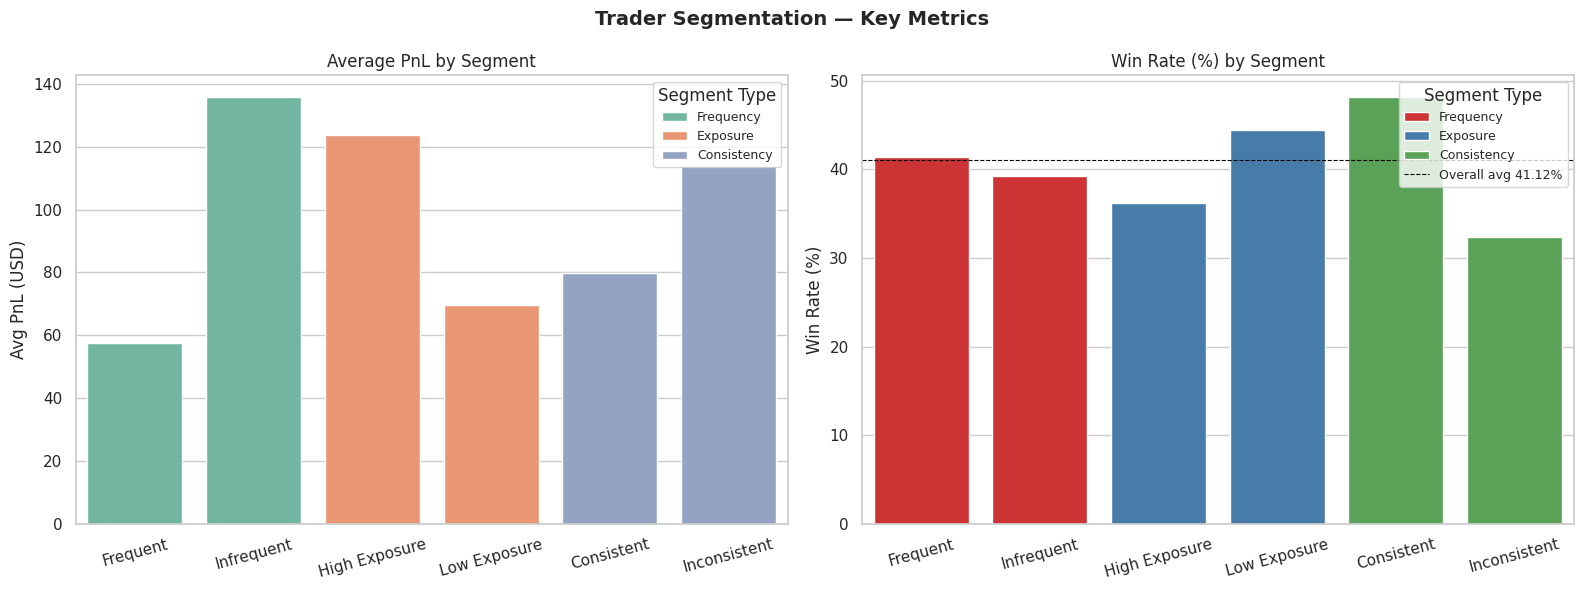

In [59]:
# GROUPED BAR CHART FOR AVERAGE PNL AND WIN RATE

seg_data = []

for seg_col, seg_name in [('Frequency_Segment', 'Frequency'),
                            ('Exposure_Segment', 'Exposure'),
                            ('Consistency_Segment', 'Consistency')]:
    temp = trader_profile.groupby(seg_col)[['Avg_PnL', 'Win_Rate']].mean().reset_index()
    temp.columns = ['Segment', 'Avg_PnL', 'Win_Rate']
    temp['Win_Rate'] = temp['Win_Rate'] * 100
    temp['Type'] = seg_name
    seg_data.append(temp)

seg_long = pd.concat(seg_data, ignore_index=True)

# plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Trader Segmentation — Key Metrics', fontsize=14, fontweight='bold')

# Avg PnL by segment
sns.barplot(data=seg_long, x='Segment', y='Avg_PnL',
            hue='Type', ax=axes[0], palette='Set2')
axes[0].set_title('Average PnL by Segment')
axes[0].set_ylabel('Avg PnL (USD)')
axes[0].set_xlabel('')
axes[0].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Segment Type', fontsize=9)

# Win Rate by segment
sns.barplot(data=seg_long, x='Segment', y='Win_Rate',
            hue='Type', ax=axes[1], palette='Set1')
axes[1].set_title('Win Rate (%) by Segment')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_xlabel('')
axes[1].axhline(y=41.12, color='black', linewidth=0.8,
                linestyle='--', label='Overall avg 41.12%')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Segment Type', fontsize=9)

plt.tight_layout()
plt.savefig('chart7_segmentation_grouped.png', dpi=150, bbox_inches='tight')
plt.show()


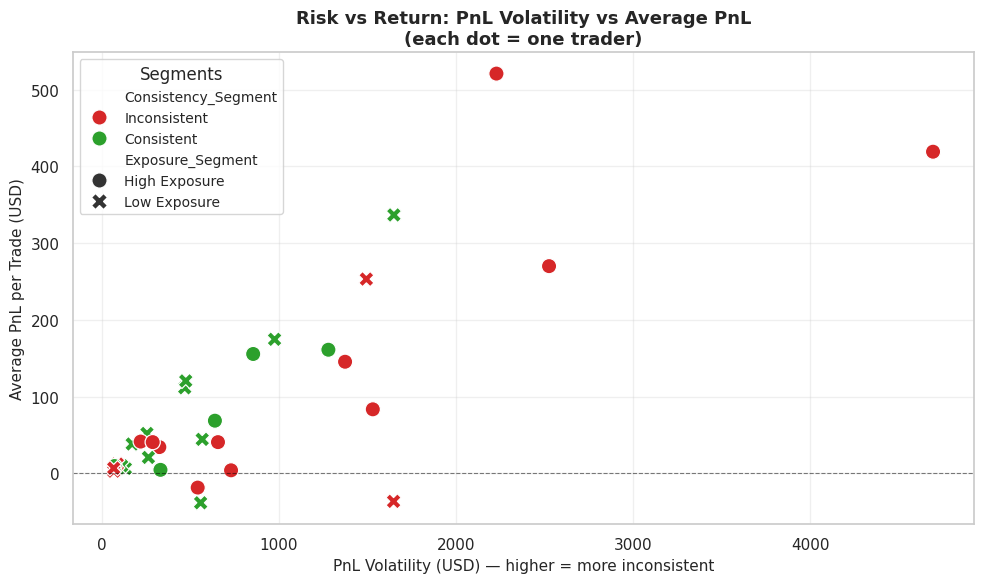

In [60]:
# AVERAGE PNL VS PNL VOLATILITY SCATTER CHART

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(data=trader_profile,
                x='PnL_Volatility',
                y='Avg_PnL',
                hue='Consistency_Segment',
                style='Exposure_Segment',
                palette={'Consistent': '#2ca02c', 'Inconsistent': '#d62728'},
                s=120,
                ax=ax)

ax.set_xlabel('PnL Volatility (USD) — higher = more inconsistent', fontsize=11)
ax.set_ylabel('Average PnL per Trade (USD)', fontsize=11)
ax.set_title('Risk vs Return: PnL Volatility vs Average PnL\n(each dot = one trader)',
             fontsize=13, fontweight='bold')
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)
ax.legend(title='Segments', fontsize=10)

plt.tight_layout()
plt.savefig('chart8_pnl_vs_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

#### **Question 3 Summary — Trader Segmentation**

We segmented 32 traders into 3 behavioural groups using median thresholds.

---

**Segment 1: Frequent vs Infrequent Traders**
(Threshold: 3,699 trades — median)

- Infrequent traders earn significantly more per trade ($136) vs Frequent traders ($57)
- Despite trading less, infrequent traders are more selective —
  they wait for higher conviction opportunities
- Frequent traders show lower volatility ($763) vs infrequent ($942) —
  they are more consistent but less profitable per trade
- Insight: More trading does not mean more profit in this dataset

---

**Segment 2: High vs Low Exposure Traders**
(Threshold: $3,328 avg trade size — median)

- High Exposure traders earn more per trade ($123) vs Low Exposure ($69)
- However High Exposure traders have a LOWER win rate (36%) vs Low Exposure (44%)
- They win less often but win bigger — classic high risk high reward pattern
- PnL volatility of High Exposure traders ($1,143) is double Low Exposure ($562)
- Insight: Bigger position sizes increase returns but also increase risk significantly

---

**Segment 3: Consistent vs Inconsistent Traders**
(Threshold: 40% win rate — median)

- Consistent traders win 48% of trades vs only 32% for Inconsistent traders
- Inconsistent traders have higher avg PnL ($113) vs Consistent ($79) —
  driven by occasional very large winning trades
- But Inconsistent traders have double the volatility ($1,155 vs $550) —
  their results are unpredictable
- Insight: Consistent traders are more reliable and sustainable —
  Inconsistent traders occasionally get lucky but cannot sustain it

---

**Overall Segmentation Takeaway**

The most sustainable trading profile in this dataset is:
Low frequency + Low to High exposure + High consistency —
trade selectively, manage position size, maintain win rate above 40%.

## **Question 4: Key Insights**

The analyses performed in Questions 1–3 reveal several notable patterns in trader performance, trading behaviour, and trader segmentation. The following section summarizes the three most significant insights, each supported by appropriate tables.

#### ***Insight 1:***

---




Greed days produced the highest average PnL (53.88 USD), but they also recorded the largest downside risk with a drawdown proxy of -117,990.10 USD. This indicates that higher profitability during optimistic market conditions comes at the cost of significantly higher risk.

In [71]:
print("=== INSIGHT 1: Fear vs Greed Performance ===")

insight1 = merged.groupby('sentiment').agg(
    Avg_PnL=('Closed PnL', 'mean'),
    Drawdown_Proxy=('Closed PnL', 'min')
).round(2)

display(insight1)

=== INSIGHT 1: Fear vs Greed Performance ===


,Avg_PnL,Drawdown_Proxy
sentiment,,
Fear,49.21,-35681.75
Greed,53.88,-117990.10
Neutral,34.31,-24500.00


#### ***Insight 2:***

---



The average position size was highest during Fear periods (7,182 USD), suggesting that traders committed larger amounts of capital when market sentiment was pessimistic.

In [72]:
print("\n=== INSIGHT 2: Position Sizing by Sentiment ===")

insight2 = merged.groupby('sentiment').agg(
    Avg_Position_Size=('Size USD', 'mean')
).round(2)

display(insight2)


=== INSIGHT 2: Position Sizing by Sentiment ===


,Avg_Position_Size
sentiment,
Fear,7182.01
Greed,4574.42
Neutral,4782.73


#### ***Insight 3:***

---



Infrequent traders achieved a higher average PnL per trade than frequent traders, despite having a slightly lower win rate. This suggests that making fewer but more selective trades may be more profitable than trading very frequently.

In [74]:
print("\n=== INSIGHT 3: Infrequent vs Frequent PnL ===")

insight3 = trader_profile.groupby('Frequency_Segment').agg(
    Avg_PnL=('Avg_PnL', 'mean'),
    Win_Rate=('Win_Rate', 'mean')
).round(3)

insight3['Win_Rate'] = (insight3['Win_Rate'] * 100).round(2)

display(insight3)


=== INSIGHT 3: Infrequent vs Frequent PnL ===


,Avg_PnL,Win_Rate
Frequency_Segment,,
Frequent,57.577,41.4
Infrequent,136.005,39.2


# ***Part C — “Actionable output”***

## **Strategy 1:**
### ***Implement Sentiment-Based Risk Management***

---



The analysis showed that **Greed** periods generated the highest average profit per trade (53.88 USD), but they also recorded the largest drawdown proxy (-117,990.10 USD). At the same time, the win rate remained almost the same across all market sentiments (40–42%). This indicates that the higher returns during Greed periods came with significantly greater downside risk rather than a higher probability of winning trades



#### **Recommendation:**

---



Instead of treating market sentiment as a direct signal to trade more aggressively, it should be used as a guide for managing risk. During Greed periods, traders should avoid increasing their exposure simply because market conditions appear favourable. Maintaining disciplined position sizing, using appropriate stop-loss levels, and following predefined risk limits can help protect capital while still allowing traders to benefit from profitable market opportunities.

## **Strategy 2:**
### ***Prioritize Trade Quality Over Trade Quantity***

---



The trader segmentation analysis showed that **infrequent traders earned a higher average profit per trade than frequent traders**, even though their win rate was slightly lower. This suggests that executing a larger number of trades does not necessarily lead to better profitability. Instead, taking fewer but well-planned trades appears to produce better results.


#### **Recommendation:**

---




Rather than aiming to increase the number of trades, traders should focus on identifying high-quality trading opportunities that meet predefined entry and risk criteria. A disciplined and selective trading approach can help improve overall profitability while avoiding unnecessary trades and reducing exposure to avoidable market risks.